In [2]:
import json
import sys
import pandas as pd
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["CUDA_LAUNCH_BLOCKING"] = "3"
import numpy as np
sys.path.insert(0, '..')
from src.experiment_utils.helper_classes import token, span, repository
from src.d02_corpus_statistics.corpus import Corpus
import types
from owlready2 import sync_reasoner
from collections import Counter
from transformers import pipeline, AutoModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoModelForTokenClassification, DataCollatorForTokenClassification, TrainingArguments, Trainer
import spacy
from spacy.training import offsets_to_biluo_tags
from datasets import Dataset, DatasetDict
import torch
import torch.nn as nn
import evaluate
from sklearn.metrics import f1_score

cwd = os.getcwd()
pol_dir = cwd+"/../src/d01_data"

/home/marwas/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pol_df = pd.read_pickle(pol_dir+"/preprocessed_dataframe.pkl")[["Policy","Text","Tokens","Curation"]]

## BIO (Maybe BILOU for multi-head classif)

#### Trying all feature types at the same time first

In [12]:
# convert the dataframe of span labels to a hf dataset of BIO tags
def extract_labels(df):
    labels = set()
    for spancoll in df["Curation"]:
        for spn in spancoll:
            if spn.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                ftr = spn.feature
                if ftr not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    label = ftr
                    labels.add(label)
    bio_labels = ["O"]
    for l in sorted(labels):
        bio_labels.append(f"B-{l}")
        bio_labels.append(f"I-{l}")
    return bio_labels

def span_to_bio_tok_lbls(tokens, spans, label2id):
    token_labels = ["O"] * len(tokens)
    for spn in spans:
        if spn.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                ftr = spn.feature
                if ftr not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    start_char = spn.start
                    end_char = spn.stop
                    #
                    inside_tokens = []
                    for i, tok in enumerate(tokens):
                        tok_start = tok.start
                        tok_end = tok.stop
                        overlap = not (tok_end <= start_char or tok_start >= end_char)
                        if overlap:
                            inside_tokens.append(i)
                    if inside_tokens:
                        token_labels[inside_tokens[0]] = f"B-{ftr}"
                        for i in inside_tokens[1:]:
                            token_labels[i] = f"I-{ftr}"
    return [label2id[l] for l in token_labels]

def df_to_dataset(df):
    dataset = {
        "id":[],
        "text":[],
        "tokens":[],
        "ner_tags":[]
    }
    label_list = extract_labels(df)
    label2id = {l: i for i, l in enumerate(label_list)}
    for artid in df.index:
        tokens = df.loc[artid,"Tokens"]
        if len(tokens) <= 512: # we'll change this eventually
            text = df.loc[artid,"Text"]
            spans = df.loc[artid,"Curation"]
            token_texts = [t.text for t in tokens]
            token_level_labels = span_to_bio_tok_lbls(tokens, spans, label2id)
            dataset['id'].append(artid)
            dataset["text"].append(text)
            dataset["tokens"].append(token_texts)
            dataset["ner_tags"].append(token_level_labels)
    return Dataset.from_dict(dataset), label_list

In [13]:
dataset, label_list = df_to_dataset(pol_df)
id2label = {}
label2id = {}
for i, lbl in enumerate(label_list):
    id2label[i] = lbl
    label2id[lbl] = i
#print(id2label, label2id)
'''
for r in [0,1,2]:
    td_test = dataset.train_test_split(test_size=0.2, seed=r)
    train_dev = td_test['train'].train_test_split(test_size=0.25, seed=r)
    ds_dct = DatasetDict({"train":train_dev['train'], "dev":train_dev['test'], "test":td_test['test']})
    print(ds_dct)
    ds_dct.save_to_disk(cwd+f"/inputs/dsdct_r{r}")
'''

'\nfor r in [0,1,2]:\n    td_test = dataset.train_test_split(test_size=0.2, seed=r)\n    train_dev = td_test[\'train\'].train_test_split(test_size=0.25, seed=r)\n    ds_dct = DatasetDict({"train":train_dev[\'train\'], "dev":train_dev[\'test\'], "test":td_test[\'test\']})\n    print(ds_dct)\n    ds_dct.save_to_disk(cwd+f"/inputs/dsdct_r{r}")\n'

In [5]:
# preprocessing tokens field
model_name = "microsoft/deberta-v3-base" # suggested lr of 3e-5
#model_name = "dslim/bert-base-NER-uncased"
#model_name = "FacebookAI/xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_and_align_labels(examples):
    # fxn from https://huggingface.co/docs/transformers/en/tasks/token_classification
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples[f"ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

/home/marwas/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [6]:
#r = 0
for r in [0,1,2]:
    model_name = "FacebookAI/xlm-roberta-base"
    dataset_dict = DatasetDict.load_from_disk(cwd+f"/inputs/dsdct_r{r}")
    tokenized_dsdct = dataset_dict.map(tokenize_and_align_labels, batched=True)
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
    #
    seqeval = evaluate.load("seqeval")
    def compute_metrics(p):
        # fxn from https://huggingface.co/docs/transformers/en/tasks/token_classification
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_predictions = [
            [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        true_labels = [
            [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        results = seqeval.compute(predictions=true_predictions, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }
    #torch.cuda.empty_cache()
    model = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=len(label_list), id2label=id2label, label2id=label2id,
        #ignore_mismatched_sizes=True #only for "dslim/bert-base-NER-uncased"
    )
    print(model_name, "loaded.")
    #
    training_args = TrainingArguments(
        output_dir=model_name.split("/")[-1],
        learning_rate=3e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=15,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dsdct["train"],
        eval_dataset=tokenized_dsdct["dev"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    print("Training begin")
    #trainer.train()
    #trainer.save_model(cwd+f"/models/{model_name.split('/')[-1]}_{r}")
    del model
    del trainer

FileNotFoundError: No such file: '/home/marwas/POLIANNA/notebooks/inputs/dsdct_r0/dataset_dict.json'. Expected to load a `DatasetDict` object, but provided path is not a `DatasetDict`.

ok so i have first run 
AutoModelForTokenClassification, all
microsoft/deberta-v3-base lr 3E-5 epochs 10 r 0-2 # tokenizer was deberta
FacebookAI/xlm-roberta-base lr 3E-5 epochs 15 r 0-2 #tokenizer was roberta
dslim/bert-base-NER-uncased lr 3E-5 epochs 10 r 0-2 #tokenizer was bert

will need to try
AutoModelForSeq2SeqLM
#model_name = "dslim/bert-base-NER-uncased"
model_name = "Babelscape/mrebel-large" #AutoModelForSeq2SeqLM
#model_name = "sentence-transformers/gtr-t5-base"

#### Now separate classification heads

https://medium.com/@shahrukhx01/multi-task-learning-with-transformers-part-1-multi-prediction-heads-b7001cf014bf

In [7]:
def span_to_bio_tok_lbls(feature_name, tokens, spans, label2id):
    token_labels = ["O"] * len(tokens)
    for spn in spans:
        if spn.feature == feature_name:
            start_char = spn.start
            end_char = spn.stop
            inside_tokens = []
            for i, tok in enumerate(tokens):
                tok_start = tok.start
                tok_end = tok.stop
                overlap = not (tok_end <= start_char or tok_start >= end_char)
                if overlap:
                    inside_tokens.append(i)
            if inside_tokens:
                token_labels[inside_tokens[0]] = f"B"
                for i in inside_tokens[1:]:
                    token_labels[i] = f"I"
    return [label2id[l] for l in token_labels]

def df_to_dataset(df):
    label2id = {
        "O":0, "B":1, "I":2
    }
    dataset = {
        "id":[],
        "text":[],
        "tokens":[],
        "labels_Actor":[],
        "labels_InstrumentType":[],
        "labels_Objective":[],
        "labels_Resource":[],
        "labels_Time":[]
    }
    for artid in df.index:
        tokens = df.loc[artid,"Tokens"]
        if len(tokens) <= 512: # we'll change this eventually
            text = df.loc[artid,"Text"]
            spans = df.loc[artid,"Curation"]
            token_texts = [t.text for t in tokens]
            dataset['id'].append(artid)
            dataset["text"].append(text)
            dataset["tokens"].append(token_texts)
            for ftr in ["Actor", "InstrumentType", "Objective", "Resource", "Time"]:
                token_level_labels = span_to_bio_tok_lbls(ftr, tokens, spans, label2id)
                dataset[f"labels_{ftr}"].append(token_level_labels)
    return Dataset.from_dict(dataset), list(label2id)

In [8]:
dataset, label_list = df_to_dataset(pol_df)
id2label = {}
label2id = {}
for i, lbl in enumerate(label_list):
    id2label[i] = lbl
    label2id[lbl] = i

# do the datasets need to differ by model used for tokenization of results too??

In [9]:
# preprocessing tokens field
model_name = "microsoft/deberta-v3-base" # suggested lr of 3e-5
#model_name = "dslim/bert-base-NER-uncased"
#model_name = "FacebookAI/xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    # fxn from https://huggingface.co/docs/transformers/en/tasks/token_classification
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples[f"ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [10]:
'''
for r in [0,1,2]:
    td_test = dataset.train_test_split(test_size=0.2, seed=r)
    train_dev = td_test['train'].train_test_split(test_size=0.25, seed=r)
    ds_dct = DatasetDict({"train":train_dev['train'], "dev":train_dev['test'], "test":td_test['test']})
    print(ds_dct)
    ds_dct.save_to_disk(cwd+f"/inputs/sep/dsdct_r{r}")
'''

'\nfor r in [0,1,2]:\n    td_test = dataset.train_test_split(test_size=0.2, seed=r)\n    train_dev = td_test[\'train\'].train_test_split(test_size=0.25, seed=r)\n    ds_dct = DatasetDict({"train":train_dev[\'train\'], "dev":train_dev[\'test\'], "test":td_test[\'test\']})\n    print(ds_dct)\n    ds_dct.save_to_disk(cwd+f"/inputs/sep/dsdct_r{r}")\n'

In [11]:
for r in [0]:#[0,1,2]:
    model_name = "microsoft/deberta-v3-base"
    dataset_dict = DatasetDict.load_from_disk(cwd+f"/inputs/sep/dsdct_r{r}")
    tokenized_dsdct = dataset_dict.map(tokenize_and_align_labels, batched=True)
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
    #
    seqeval = evaluate.load("seqeval")
    def compute_metrics(p):
        # fxn from https://huggingface.co/docs/transformers/en/tasks/token_classification
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_predictions = [
            [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        true_labels = [
            [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        results = seqeval.compute(predictions=true_predictions, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }
    #torch.cuda.empty_cache()
    model = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=len(label_list), id2label=id2label, label2id=label2id,
        #ignore_mismatched_sizes=True #only for "dslim/bert-base-NER-uncased"
    )
    print(model_name, "loaded.")
    #
    training_args = TrainingArguments(
        output_dir=model_name.split("/")[-1],
        learning_rate=3e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=15,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dsdct["train"],
        eval_dataset=tokenized_dsdct["dev"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    print("Training begin")
    trainer.train()
    trainer.save_model(cwd+f"/models/sep/{model_name.split('/')[-1]}_{r}")
    del model
    del trainer

Map:   0%|          | 0/190 [00:00<?, ? examples/s]


KeyError: 'ner_tags'

#### Test Stage

In [12]:
seqeval = evaluate.load("seqeval")
results_dict = {
    "microsoft/deberta-v3-base":{},
    "FacebookAI/xlm-roberta-base":{},
    "dslim/bert-base-NER-uncased":{}
}
for model_name in list(results_dict):
    results_dict[model_name]["Overall"] = {"precision":[], "recall":[], "f1":[], "accuracy":[]}
    for ftr in ["Actor", "InstrumentType", "Objective", "Resource", "Time"]:
        results_dict[model_name][ftr] = {"precision":[], "recall":[], "f1":[], "number":[]}
for model_name in list(results_dict):
    for r in [0,1,2]:
        dataset_dict = DatasetDict.load_from_disk(cwd+f"/inputs/all/dsdct_r{r}")
        model_tt = AutoModelForTokenClassification.from_pretrained(cwd+f"/models/all/{model_name.split('/')[-1]}_{r}")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        classifier = pipeline("ner", model = model_tt, tokenizer=tokenizer)
        inputs = tokenizer(list(dataset_dict['test']['text']), return_tensors="pt", padding=True, truncation=True)
        device = torch.device("cuda")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model_tt(**inputs).logits
        predictions = torch.argmax(logits, dim=2)
        seqeval = evaluate.load("seqeval")
        labels = list(dataset_dict['test']['ner_tags'])
        true_predictions = [
            [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        true_labels = [
            [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        results = seqeval.compute(predictions=true_predictions, references=true_labels)
        for k in list(results):
            if k[:4]=="over":
                x, metric = k.split("_")
                results_dict[model_name]['Overall'][metric].append(float(results[k]))
            else:
                for mtr in list(results[k]):
                    results_dict[model_name][k][mtr].append(float(results[k][mtr]))           

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Device set to use cuda:0
/home/marwas/miniconda3/envs/kgenv/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


In [13]:
for m in list(results_dict):
    print(f"\n{m}")
    for res in list(results_dict[m]):
        print(f"{res}")
        print(results_dict[m][res])


microsoft/deberta-v3-base
Overall
{'precision': [0.06, 0.09873708381171067, 0.08595194085027727], 'recall': [0.06923076923076923, 0.11590296495956873, 0.10379464285714286], 'f1': [0.06428571428571428, 0.10663360198388096, 0.09403437815975732], 'accuracy': [0.7546543066821166, 0.783454356846473, 0.7574223766714512]}
Actor
{'precision': [0.10141987829614604, 0.18309859154929578, 0.14446952595936793], 'recall': [0.10706638115631692, 0.17015706806282724, 0.15384615384615385], 'f1': [0.10416666666666667, 0.17639077340569878, 0.1490104772991851], 'number': [467.0, 382.0, 416.0]}
InstrumentType
{'precision': [0.04225352112676056, 0.08016877637130802, 0.0718562874251497], 'recall': [0.046511627906976744, 0.09693877551020408, 0.08921933085501858], 'f1': [0.04428044280442804, 0.08775981524249422, 0.07960199004975124], 'number': [258.0, 196.0, 269.0]}
Objective
{'precision': [0.0, 0.015748031496062992, 0.017241379310344827], 'recall': [0.0, 0.029411764705882353, 0.02564102564102564], 'f1': [0.0,

In [14]:
fn = "first_results"
with open(cwd+f"/outputs/{fn}.json", "w", encoding="utf-8") as f:
    json.dump(results_dict, f, indent=4)

In [15]:
for m in list(results_dict):
    print(f"\n{m}")
    for res in list(results_dict[m]):
        print(f"\n{res}")
        df = pd.DataFrame(results_dict[m][res])
        df.loc['mean'] = df.mean()
        print(df)


microsoft/deberta-v3-base

Overall
      precision    recall        f1  accuracy
0      0.060000  0.069231  0.064286  0.754654
1      0.098737  0.115903  0.106634  0.783454
2      0.085952  0.103795  0.094034  0.757422
mean   0.081563  0.096309  0.088318  0.765177

Actor
      precision    recall        f1      number
0      0.101420  0.107066  0.104167  467.000000
1      0.183099  0.170157  0.176391  382.000000
2      0.144470  0.153846  0.149010  416.000000
mean   0.142996  0.143690  0.143189  421.666667

InstrumentType
      precision    recall        f1  number
0      0.042254  0.046512  0.044280   258.0
1      0.080169  0.096939  0.087760   196.0
2      0.071856  0.089219  0.079602   269.0
mean   0.064760  0.077557  0.070547   241.0

Objective
      precision    recall        f1     number
0      0.000000  0.000000  0.000000  62.000000
1      0.015748  0.029412  0.020513  68.000000
2      0.017241  0.025641  0.020619  78.000000
mean   0.010996  0.018351  0.013710  69.333333

Reso

In [7]:
torch.cuda.empty_cache()

In [18]:
mode = "all"
results_dict = {
    "microsoft/deberta-v3-base":{},
    "FacebookAI/xlm-roberta-base":{},
    "dslim/bert-base-NER-uncased":{}
}
for model_name in list(results_dict):
    #results_dict[model_name]["Overall"] = {"precision":[], "recall":[], "f1":[], "accuracy":[]}
    for ftr in ["Actor", "InstrumentType", "Objective", "Resource", "Time"]:
        results_dict[model_name][ftr] = {"f1":[]}
for model_name in list(results_dict):
    for r in [0,1,2]:
        dataset_dict = DatasetDict.load_from_disk(cwd+f"/inputs/{mode}/dsdct_r{r}")
        model_tt = AutoModelForTokenClassification.from_pretrained(cwd+f"/models/{mode}/{model_name.split('/')[-1]}_{r}")
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        tokenized_dsdct = dataset_dict.map(tokenize_and_align_labels, batched=True)
        model_tt.to('cuda')
        model_tt.eval()
        texts = list(tokenized_dsdct['test']['text'])
        # tokenize batch
        '''
        inputs = {
            "input_ids": torch.tensor(tokenized_dsdct['test']['input_ids']).to('cuda'),
            "attention_mask": torch.tensor(tokenized_dsdct['test']['attention_mask']).to('cuda')
        }
        labels_tensor = torch.tensor(tokenized_dsdct['test']['labels']).to("cuda")
        '''
        data_collator = DataCollatorForTokenClassification(tokenizer, padding=True)
        tokenized_test = tokenized_dsdct['test'].remove_columns(['id', 'text', 'tokens', 'ner_tags'])
        batch = data_collator(tokenized_test)
        inputs = {k: v.to('cuda') for k, v in batch.items()}
        labels_tensor = inputs.pop("labels")
        with torch.no_grad():
            outputs = model_tt(**inputs)
            preds = outputs.logits.argmax(dim=-1)
        
        # Flatten and mask -100
        labels_flat = labels_tensor.flatten().cpu().numpy()
        preds_flat = preds.flatten().cpu().numpy()
        mask = labels_flat != -100
        labels_flat = labels_flat[mask]
        preds_flat = preds_flat[mask]
        
        # Compute F1
        f1 = f1_score(labels_flat, preds_flat, average='micro')  # or 'micro' if desired
        #print(f1)
        #results_dict[model_name]["f1"].append(f1)
        print(f"{model_name} r{r} F1: {f1:.4f}")

/home/marwas/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


microsoft/deberta-v3-base r0 F1: 0.8983


/home/marwas/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Map: 100%|██████████| 190/190 [00:00<00:00, 1163.13 examples/s]


microsoft/deberta-v3-base r1 F1: 0.8990


/home/marwas/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Map: 100%|██████████| 64/64 [00:00<00:00, 1419.05 examples/s]


...

dslim/bert-base-NER-uncased r0 F1: 0.8995


Map: 100%|██████████| 64/64 [00:00<00:00, 1118.02 examples/s]


dslim/bert-base-NER-uncased r1 F1: 0.8994


Map: 100%|██████████| 64/64 [00:00<00:00, 1054.38 examples/s]


dslim/bert-base-NER-uncased r2 F1: 0.8884


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][0])
for idx, tok in enumerate(tokens[:50]):
    print(f"{idx:03} | {tok:15} | "
          f"A:{batch['labels_Actor'][0][idx].item():2}  "
          f"T:{batch['labels_Time'][0][idx].item():2}  "
          f"I:{batch['labels_InstrumentType'][0][idx].item():2}")

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 190
    })
    dev: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 64
    })
    test: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 64
    })
})

In [13]:
results_dir = cwd+"/results"

def df_vis_consol_sghead_seqeval(results_dict):
    for m in list(results_dict):
        print(f"\n{m}")
        for res in list(results_dict[m]):
            print(f"\n{res}")
            df = pd.DataFrame(results_dict[m][res])
            print(df)
            df.loc['mean'] = df.mean()
            print(df)

with open(f"{results_dir}/sghead/seqeval_results.json","r", encoding="utf-8") as f:
        results_dict = json.load(f)
df_vis_consol_sghead_seqeval(results_dict)


microsoft/deberta-v3-base

Overall
   precision    recall        f1  accuracy
0   0.560463  0.585071  0.572503  0.898325
1   0.539974  0.555256  0.547508  0.898961
2   0.562307  0.608696  0.584582  0.892951
      precision    recall        f1  accuracy
0      0.560463  0.585071  0.572503  0.898325
1      0.539974  0.555256  0.547508  0.898961
2      0.562307  0.608696  0.584582  0.892951
mean   0.554248  0.583008  0.568198  0.896746

Actor
   precision    recall        f1  number
0   0.852525  0.901709  0.876428   468.0
1   0.814607  0.759162  0.785908   382.0
2   0.808889  0.872902  0.839677   417.0
      precision    recall        f1      number
0      0.852525  0.901709  0.876428  468.000000
1      0.814607  0.759162  0.785908  382.000000
2      0.808889  0.872902  0.839677  417.000000
mean   0.825340  0.844591  0.834004  422.333333

InstrumentType
   precision    recall        f1  number
0   0.273973  0.310078  0.290909   258.0
1   0.413333  0.474490  0.441805   196.0
2   0.406832

### Spans

In [3]:
ner_lst = []
for artid in list(pol_df.index):
    # will remove later when we bring in chunking, but for now let's just play with the short articles
    if len(pol_df.loc[artid, "Text"]) > 512:
        entry = {
            "art_id": artid,
            "text": pol_df.loc[artid, "Text"],
            "entities":[]
        }
        for span in pol_df.loc[artid, "Curation"]:
            if span.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                if span.feature not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    entry['entities'].append({
                        "start": span.start,
                        "stop": span.stop,
                        "feature": span.feature,
                        "tag": span.tag,
                        "span_id": f"{artid}_{span.span_id}",
                        "text": span.text
                    })
        ner_lst.append(entry)

12 15348 588.7321428571429 267.0


(array([327.,  76.,  21.,   5.,   7.,   2.,   0.,   1.,   1.,   1.,   0.,
          1.,   1.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([1.20000000e+01, 5.40827586e+02, 1.06965517e+03, 1.59848276e+03,
        2.12731034e+03, 2.65613793e+03, 3.18496552e+03, 3.71379310e+03,
        4.24262069e+03, 4.77144828e+03, 5.30027586e+03, 5.82910345e+03,
        6.35793103e+03, 6.88675862e+03, 7.41558621e+03, 7.94441379e+03,
        8.47324138e+03, 9.00206897e+03, 9.53089655e+03, 1.00597241e+04,
        1.05885517e+04, 1.11173793e+04, 1.16462069e+04, 1.21750345e+04,
        1.27038621e+04, 1.32326897e+04, 1.37615172e+04, 1.42903448e+04,
        1.48191724e+04, 1.53480000e+04]),
 <BarContainer object of 29 artists>)

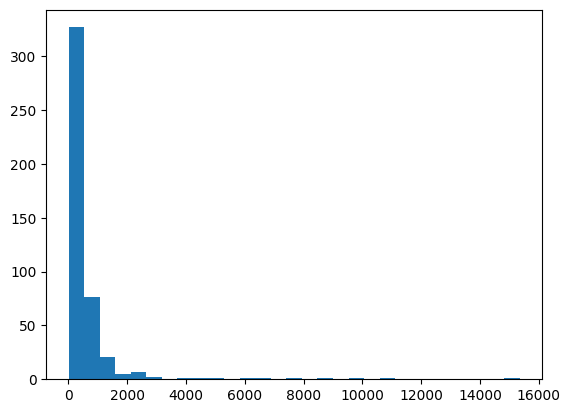

In [4]:
tokens_per_art = []
for artid in list(pol_df.index):
    tokens_per_art.append(len(pol_df.loc[artid, "Tokens"]))
print(np.min(tokens_per_art), np.max(tokens_per_art), np.mean(tokens_per_art), np.median(tokens_per_art))
import matplotlib.pyplot as plt
plt.hist(tokens_per_art, bins=int(15348/512))
#plt.hist(tokens_per_art, bins=int(15348/1024))
#plt.ylim(0,25)

In [5]:
articles = [entry["text"] for entry in ner_lst]
entity_lists = [entry["entities"] for entry in ner_lst]
print(len(articles),len(entity_lists))
#
feature_names = []
for entity_coll in entity_lists:
    for entity in entity_coll:
        feature_names.append(entity['feature'])
Counter(feature_names)

360 360


Counter({'Actor': 5878,
         'InstrumentType': 3320,
         'Objective': 973,
         'Time': 743,
         'Resource': 506})

In [9]:
from sklearn.model_selection import train_test_split
art_tr, art_test, el_tr, el_test = train_test_split(articles, entity_lists, test_size=0.2, random_state=0)
art_train, art_dev, el_train, el_dev = train_test_split(art_tr, el_tr, test_size=0.25, random_state=0)

Experiment with 

FacebookAI/xlm-roberta-base

microsoft/deberta-v3-base   #potential

dslim/bert-base-NER (doesnt work)

dslim/bert-base-NER-uncased

mawaskow/inc_sent_cls_[bn/mc]

Babelscape/rebel-large

Babelscape/mrebel-large

sentence-transformers/gtr-t5-base   #potential

BART
T5 linearization

spaCy: en_core_web_trf

BertForTokenClassification


# CHECK THIS AGAINST EXISTING METHODS

In [7]:
# Convert to 
from datasets import Dataset
from transformers import AutoTokenizer
import torch

dataset = Dataset.from_list(ner_lst)
print("Loading tokenizer")
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Build label mapping
all_labels = sorted({ent["feature"] for d in ner_lst for ent in d["entities"]})
label2id = {l: i for i, l in enumerate(all_labels)}
id2label = {i: l for l, i in label2id.items()}

# Tokenize and align spans
def encode_spans(example):
    encoding = tokenizer(example["text"], return_offsets_mapping=True, truncation=True)
    seq_len = len(encoding["input_ids"])

    start_labels = torch.zeros(seq_len, dtype=torch.long)
    end_labels = torch.zeros(seq_len, dtype=torch.long)

    for ent in example["entities"]:
        for i, (start, end) in enumerate(encoding["offset_mapping"]):
            if start < ent["stop"] and end > ent["start"]:
                if start <= ent["start"] < end:
                    start_labels[i] = label2id[ent["feature"]] + 1  # +1 so 0 can mean "no entity"
                if start < ent["stop"] <= end:
                    end_labels[i] = label2id[ent["feature"]] + 1

    encoding["start_labels"] = start_labels.tolist()
    encoding["end_labels"] = end_labels.tolist()
    return encoding
print("Tokenizing")
tokenized_dataset = dataset.map(encode_spans)


Loading tokenizer


C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizing


Map:   0%|          | 0/448 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [8]:
from transformers import AutoModel
import torch.nn as nn

class SpanNERModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.start_classifier = nn.Linear(hidden_size, num_labels + 1)  # +1 for "no entity"
        self.end_classifier = nn.Linear(hidden_size, num_labels + 1)

    def forward(self, input_ids, attention_mask, start_labels=None, end_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        start_logits = self.start_classifier(sequence_output)
        end_logits = self.end_classifier(sequence_output)

        loss = None
        if start_labels is not None and end_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            start_loss = loss_fct(start_logits.view(-1, start_logits.shape[-1]), start_labels.view(-1))
            end_loss = loss_fct(end_logits.view(-1, end_logits.shape[-1]), end_labels.view(-1))
            loss = (start_loss + end_loss) / 2

        return {"loss": loss, "start_logits": start_logits, "end_logits": end_logits}


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(tokenized_dataset, batch_size=2, shuffle=True)

model = SpanNERModel(model_name, num_labels=len(label2id))
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

for epoch in range(3):
    model.train()
    for batch in train_loader:
        input_ids = torch.tensor(batch["input_ids"])
        attention_mask = torch.tensor(batch["attention_mask"])
        start_labels = torch.tensor(batch["start_labels"])
        end_labels = torch.tensor(batch["end_labels"])

        outputs = model(input_ids, attention_mask, start_labels, end_labels)
        loss = outputs["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch} loss: {loss.item()}")


RuntimeError: each element in list of batch should be of equal size

In [ ]:
text = "The commission issues a delegated act every year."

texts = ["The commission adopted a delegated act last year.",
        "The authority issued a new implementing regulation after five years.",
        "The parliament requested the commission to prepare a delegated act.",
        "The committee must review the measure every three years.",
        "The council approved the delegated regulation within two years.",
        "The commission may adopt further acts by the end of the year.",
        "The authority can revise the delegated act every five years.",
        "The parliament shall oversee implementation for a period of ten years.",
        "The commission published the draft delegated act earlier this month.",
        "The authority must submit a report within three months."]

for text in texts:
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        truncation=True
    )

    input_ids = torch.tensor([enc["input_ids"]])
    attention_mask = torch.tensor([enc["attention_mask"]])
    offsets = enc["offset_mapping"]
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    start_logits = outputs["start_logits"][0]   # shape: [seq_len, num_labels+1]
    end_logits = outputs["end_logits"][0]       # same
    start_preds = start_logits.argmax(dim=-1).tolist()
    end_preds = end_logits.argmax(dim=-1).tolist()

    entities = []

    for i, start_label in enumerate(start_preds):
        if start_label == 0:    # no entity begins here
            continue
        
        label = id2label[start_label - 1]   # because you added +1 during training

        # find the matching end
        for j in range(i, len(end_preds)):
            if end_preds[j] == start_label:
                char_start = offsets[i][0]
                char_end = offsets[j][1]
                span_text = text[char_start:char_end]
                
                entities.append({
                    "label": label,
                    "start": char_start,
                    "end": char_end,
                    "text": span_text
                })
                break
    print(f"\n{text}")
    for entity in entities:
        print(entity)


The commission adopted a delegated act last year.
{'label': 'Compliance', 'start': 22, 'end': 48, 'text': ' a delegated act last year'}

The authority issued a new implementing regulation after five years.
{'label': 'Compliance', 'start': 20, 'end': 68, 'text': ' a new implementing regulation after five years.'}
{'label': 'Compliance', 'start': 61, 'end': 68, 'text': ' years.'}

The parliament requested the commission to prepare a delegated act.

The committee must review the measure every three years.
{'label': 'Compliance', 'start': 13, 'end': 49, 'text': ' must review the measure every three'}

The council approved the delegated regulation within two years.
{'label': 'InstrumentType', 'start': 62, 'end': 63, 'text': '.'}

The commission may adopt further acts by the end of the year.
{'label': 'InstrumentType', 'start': 3, 'end': 40, 'text': ' commission may adopt further acts by'}
{'label': 'InstrumentType', 'start': 18, 'end': 40, 'text': ' adopt further acts by'}
{'label': 'Compl

In [ ]:
entities = []

for i, start_label in enumerate(start_preds):
    if start_label == 0:    # no entity begins here
        continue
    
    label = id2label[start_label - 1]   # because you added +1 during training

    # find the matching end
    for j in range(i, len(end_preds)):
        if end_preds[j] == start_label:
            char_start = offsets[i][0]
            char_end = offsets[j][1]
            span_text = text[char_start:char_end]
            
            entities.append({
                "label": label,
                "start": char_start,
                "end": char_end,
                "text": span_text
            })
            break


In [ ]:
entities

[{'label': 'end', 'start': 0, 'end': 23, 'text': 'The commission issues a'},
 {'label': 'Compliance',
  'start': 0,
  'end': 49,
  'text': 'The commission issues a delegated act every year.'},
 {'label': 'Compliance',
  'start': 21,
  'end': 49,
  'text': ' a delegated act every year.'},
 {'label': 'Compliance', 'start': 43, 'end': 49, 'text': ' year.'}]